In [3]:
import polars as pl

cresta_tcrdock = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.af3_tcrdock.parquet"
)
cresta_conf = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.conf_af3.parquet"
)

cresta = cresta_conf.join(
    cresta_tcrdock.select(
        [
            "job_name",
            "pred_mhc_axes_4",
            "pred_mhc_origin_4",
            "pred_tcr_axes_4",
            "pred_tcr_origin_4",
            "pred_dgeom_4",
        ]
    ),
    on="job_name",
)

template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

<Axes3D: xlabel='MHC x', ylabel='MHC y', zlabel='MHC z'>

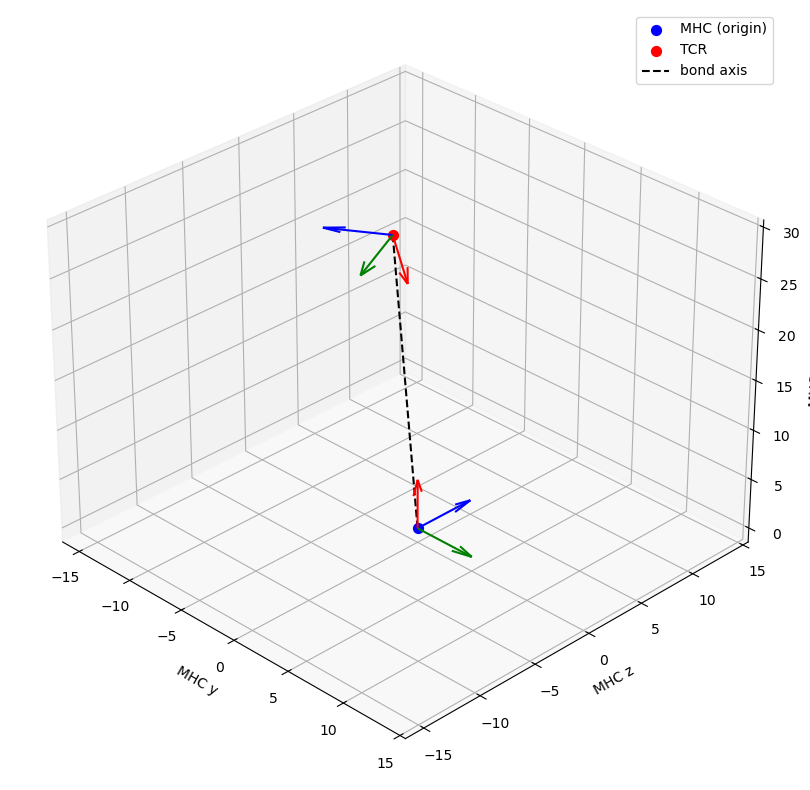

In [23]:
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.viz_utils import plot_docking_geometry
import numpy as np

dgeom_ndarr = dgeom_ndarr_from_dgeom_series(cresta.select("pred_dgeom_4").to_series())
template_dgeom_ndarr = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)
mu, invcov = mn_distr_from_dgeom_ndarr(template_dgeom_ndarr)

dist, prob = mn_distance_from(dgeom_ndarr, mu, invcov)

cresta = cresta.with_columns(pl.Series(name="mahal_dist", values=dist))

plot_docking_geometry(*un_cossin_embed(mu[np.newaxis, :])[0])

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

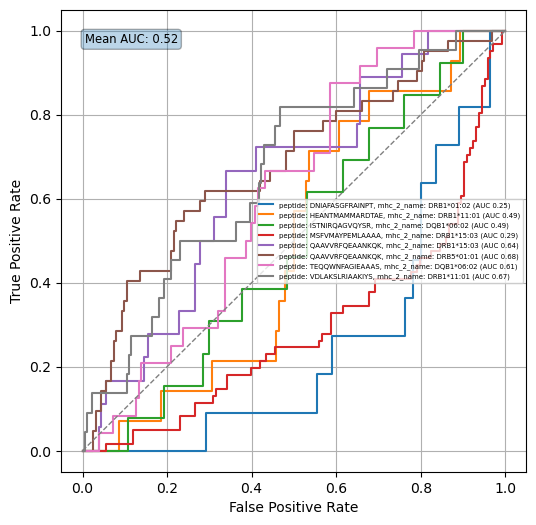

In [24]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

auc_df = antigen_raw_score_auc(
    cresta.with_columns((1 - pl.col("mahal_dist")).alias("mahal_dist")),
    "mahal_dist",
)

plot_auc_per_antigen(auc_df, id_cols=["peptide", "mhc_2_name"])

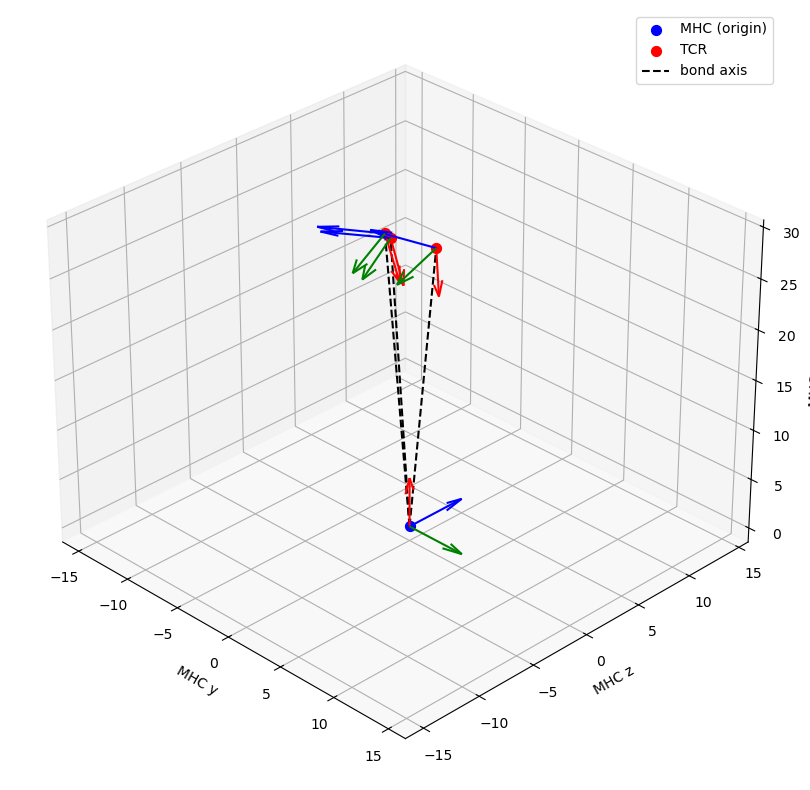

In [27]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS

mu_noncognate, _ = mn_distr_from_dgeom_ndarr(
    dgeom_ndarr_from_dgeom_series(
        cresta.join(
            auc_df.sort(by="roc_auc")[1].select(FORMAT_ANTIGEN_COLS),
            on=FORMAT_ANTIGEN_COLS,
        )
        .filter(~pl.col("cognate"))
        .select("pred_dgeom_4")
        .to_series()
    )
)

mu_cognate, _ = mn_distr_from_dgeom_ndarr(
    dgeom_ndarr_from_dgeom_series(
        cresta.join(
            auc_df.sort(by="roc_auc")[1].select(FORMAT_ANTIGEN_COLS),
            on=FORMAT_ANTIGEN_COLS,
        )
        .filter(pl.col("cognate"))
        .select("pred_dgeom_4")
        .to_series()
    )
)


ax = plot_docking_geometry(*un_cossin_embed(mu[np.newaxis, :])[0])
ax = plot_docking_geometry(*un_cossin_embed(mu_noncognate[np.newaxis, :])[0], ax=ax)
ax = plot_docking_geometry(*un_cossin_embed(mu_cognate[np.newaxis, :])[0], ax=ax)

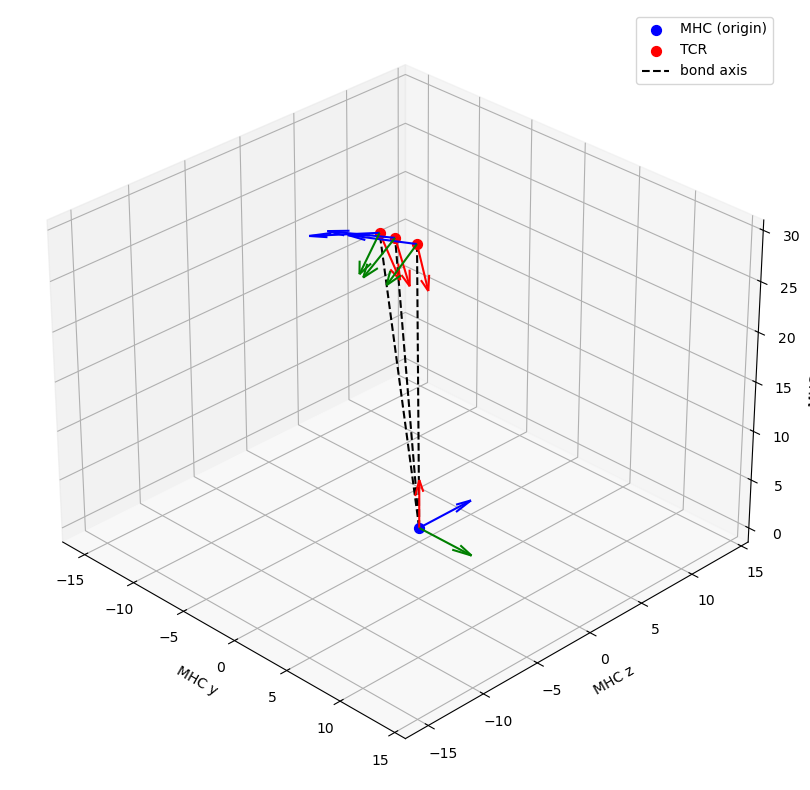

In [32]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS

mu_noncognate, _ = mn_distr_from_dgeom_ndarr(
    dgeom_ndarr_from_dgeom_series(
        cresta.join(
            auc_df.sort(by="roc_auc")[0].select(FORMAT_ANTIGEN_COLS),
            on=FORMAT_ANTIGEN_COLS,
        )
        .filter(~pl.col("cognate"))
        .select("pred_dgeom_4")
        .to_series()
    )
)

mu_cognate, _ = mn_distr_from_dgeom_ndarr(
    dgeom_ndarr_from_dgeom_series(
        cresta.join(
            auc_df.sort(by="roc_auc")[0].select(FORMAT_ANTIGEN_COLS),
            on=FORMAT_ANTIGEN_COLS,
        )
        .filter(pl.col("cognate"))
        .select("pred_dgeom_4")
        .to_series()
    )
)


ax = plot_docking_geometry(*un_cossin_embed(mu[np.newaxis, :])[0])
ax = plot_docking_geometry(*un_cossin_embed(mu_noncognate[np.newaxis, :])[0], ax=ax)
ax = plot_docking_geometry(*un_cossin_embed(mu_cognate[np.newaxis, :])[0], ax=ax)